In [106]:
# For a given sky position and frequency, compute the SNR for a point source with a given flux density.

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from pathlib import Path

%load_ext autoreload
%autoreload 2

from CHORD_Sensitivity import SkyMap
from CHORD_Sensitivity import Telescope
from CHORD_Sensitivity.constants import CLEAN_LINES

output_dir = Path("../../thesis/plots/sensitivity/")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [107]:
sky_map = SkyMap('CHORD')

nside = 1024
f = CLEAN_LINES

# Assume a uniform 10 mK peak line intensity across the sky at 1.5 GHz
f_0 = 1.5e9
x_0 = 10e-3  # 10 mK at 1.5 GHz
delta_nu = 5e3  # 5 kHz channel width
# Signal Map (This will be replaced by SIGMA data in future)
noise_sky_map = sky_map.sky_noise(delta_nu=delta_nu, freq=f, type='total_noise', CHORD_range=True)[0]
galactic_map = np.full(hp.nside2npix(nside), x_0, dtype=float)
galactic_map[np.isnan(noise_sky_map)] = np.nan

signal_map = np.empty((len(f), hp.nside2npix(nside)))
noise_map = np.empty_like(signal_map)
for i, freq in enumerate(f):
    scale_factor = freq / f_0
    noise = sky_map.sky_noise(delta_nu=delta_nu, freq=freq, type='total_noise', CHORD_range=True)[0]
    signal_map[i] = galactic_map * scale_factor
    noise_map[i] = noise * scale_factor

SNR_map = signal_map / noise_map



In [108]:
import matplotlib.pyplot as plt
sm = SkyMap("CHORD")
noise = sm.sky_noise(delta_nu=delta_nu, freq=400, type='total_noise', CHORD_range=True)[0]*1e3  # Convert to mK
med = np.nanmedian(noise)
vmin = np.nanpercentile(noise, 0)
vmax = np.nanpercentile(noise, 99)

/opt/anaconda3/envs/rrl/lib/python3.10/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


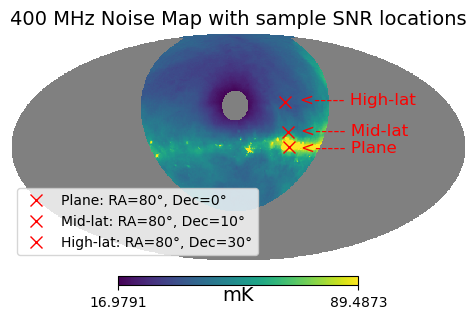

In [109]:

plt.figure(figsize=(5, 3))
hp.mollview(
    noise,
    fig=1,
    coord="C",
    title=f"400 MHz Noise Map with sample SNR locations",
    unit='mK',
    cmap="viridis",
    cbar=True,
    min=vmin,
    max=vmax,
    notext=True,
    rot=(120, 0),
)
hp.projplot(
    80,
    0,
    "rx",
    lonlat=True,
    markersize=8,
    label="Plane: RA=80°, Dec=0°",
)
hp.projtext(
    70,   # slight RA offset for readability
    -3,    # slight Dec offset for readability
    "<----- Plane",
    lonlat=True,
    color="red",
    fontsize=12,
)
hp.projplot(
    80,
    10,
    "rx",
    lonlat=True,
    markersize=8,
    label="Mid-lat: RA=80°, Dec=10°",
)
hp.projtext(
    70,   # slight RA offset for readability
    8,    # slight Dec offset for readability
    "<----- Mid-lat",
    lonlat=True,
    color="red",
    fontsize=12,
)
hp.projplot(
    80,
    30,
    "rx",
    lonlat=True,
    markersize=8,
    label="High-lat: RA=80°, Dec=30°",
)
hp.projtext(
    67,   # slight RA offset for readability
    28,    # slight Dec offset for readability
    "<----- High-lat",
    lonlat=True,
    color="red",
    fontsize=12,
)
plt.legend(loc="lower left")
plt.gca().title.set_fontsize(14)
plt.savefig(output_dir / "snr_locations.png", dpi=300, bbox_inches="tight")

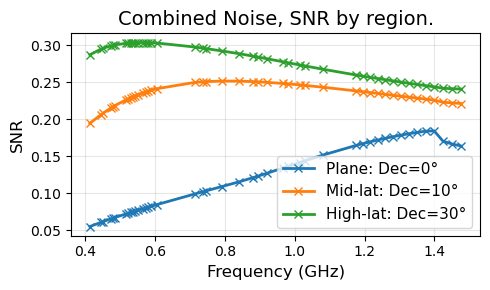

In [110]:
def radec_to_pix(ra_deg, dec_deg, nside=nside):
    ra_deg = ra_deg % 360.0
    dec_deg = np.clip(dec_deg, -90.0, 90.0)
    return hp.ang2pix(nside, ra_deg, dec_deg, lonlat=True)

plane = SNR_map[:, radec_to_pix(80, 0)]
mid_lat = SNR_map[:, radec_to_pix(80, 10)]
high_lat = SNR_map[:, radec_to_pix(80, 30)]

plt.figure(figsize=(5, 3))
plt.plot(f / 1e9, plane, label='Plane: Dec=0°', linewidth=2, marker='x')
plt.plot(f / 1e9, mid_lat, label='Mid-lat: Dec=10°', linewidth=2, marker='x')
plt.plot(f / 1e9, high_lat, label='High-lat: Dec=30°', linewidth=2, marker='x')
plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('SNR', fontsize=12)
plt.title('Combined Noise, SNR by region.', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "snr_by_region.png", dpi=300, bbox_inches="tight")

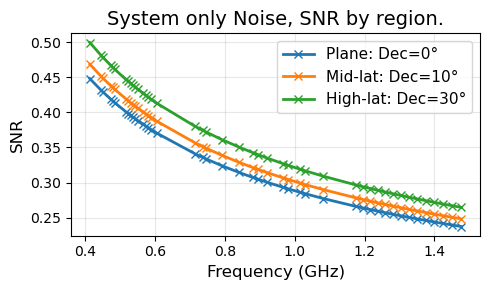

In [112]:
noise_sky_map = sky_map.sky_noise(delta_nu=delta_nu, freq=f, type='total_noise', CHORD_range=True)[0]
galactic_map = np.full(hp.nside2npix(nside), x_0, dtype=float)
galactic_map[np.isnan(noise_sky_map)] = np.nan

signal_map = np.empty((len(f), hp.nside2npix(nside)))
noise_map = np.empty_like(signal_map)
for i, freq in enumerate(f):
    scale_factor = freq / f_0
    noise = sky_map.sky_noise(delta_nu=delta_nu, freq=freq, type='system_only', CHORD_range=True)[0]
    signal_map[i] = galactic_map * scale_factor
    noise_map[i] = noise * scale_factor

SNR_map = signal_map / noise_map

plane = SNR_map[:, radec_to_pix(80, 0)]
mid_lat = SNR_map[:, radec_to_pix(80, 10)]
high_lat = SNR_map[:, radec_to_pix(80, 30)]

plt.figure(figsize=(5, 3))
plt.plot(f / 1e9, plane, label='Plane: Dec=0°', linewidth=2, marker='x')
plt.plot(f / 1e9, mid_lat, label='Mid-lat: Dec=10°', linewidth=2, marker='x')
plt.plot(f / 1e9, high_lat, label='High-lat: Dec=30°', linewidth=2, marker='x')
plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('SNR', fontsize=12)
plt.title('System only Noise, SNR by region.', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "snr_by_region_system_only.png", dpi=300, bbox_inches="tight")

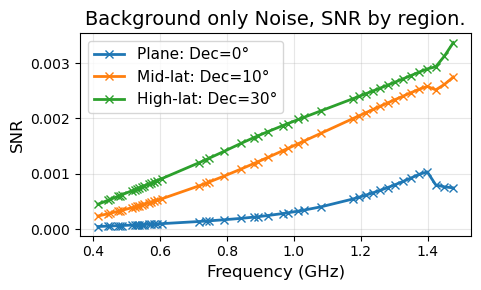

In [ ]:
noise_sky_map = sky_map.sky_noise(delta_nu=delta_nu, freq=f, type='total_noise', CHORD_range=True)[0]
galactic_map = np.full(hp.nside2npix(nside), x_0, dtype=float)
galactic_map[np.isnan(noise_sky_map)] = np.nan

signal_map = np.empty((len(f), hp.nside2npix(nside)))
noise_map = np.empty_like(signal_map)
for i, freq in enumerate(f):
    scale_factor = freq / f_0
    noise = sky_map.sky_noise(delta_nu=delta_nu, freq=freq, type='background_only', CHORD_range=True)[0]
    signal_map[i] = galactic_map * scale_factor
    noise_map[i] = noise * scale_factor

SNR_map = signal_map / noise_map

plane = SNR_map[:, radec_to_pix(80, 0)]
mid_lat = SNR_map[:, radec_to_pix(80, 10)]
high_lat = SNR_map[:, radec_to_pix(80, 30)]

plt.figure(figsize=(5, 3))
plt.plot(f / 1e9, plane, label='Plane: Dec=0°', linewidth=2, marker='x')
plt.plot(f / 1e9, mid_lat, label='Mid-lat: Dec=10°', linewidth=2, marker='x')
plt.plot(f / 1e9, high_lat, label='High-lat: Dec=30°', linewidth=2, marker='x')
plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('SNR', fontsize=12)
plt.title('Background only Noise, SNR by region.', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "snr_by_region_background_only.png", dpi=300, bbox_inches="tight")

In [ ]:
def radec_to_pix(ra_deg, dec_deg, nside=nside):
    ra_deg = ra_deg % 360.0
    dec_deg = np.clip(dec_deg, -90.0, 90.0)
    return hp.ang2pix(nside, ra_deg, dec_deg, lonlat=True)

# Example
ra_deg = 180.0
dec_deg = 30.0
pix_idx = radec_to_pix(ra_deg, dec_deg)

print("HEALPix pixel index:", pix_idx)

# If you want SNR at a specific frequency bin (example: closest to 1 GHz):
fi = np.argmin(np.abs(f - 1.0e9))
print("SNR at that sky position:", SNR_map[fi, pix_idx])

HEALPix pixel index: 3145728
SNR at that sky position: 0.24444116473293373
